In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer, QuantoConfig, VitsModel, TextStreamer
import time
import psutil
import torch
import whisper
import sounddevice as sd
import numpy as np
from IPython.display import Audio
from queue import Queue
import threading
import numpy as np
from openai import OpenAI


c:\Users\Alysha\Documents\kata-ondevice\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- LLAMA ---

model_id = "meta-llama/Llama-3.2-1B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)
quantization_config = QuantoConfig(weights="int8")

model = AutoModelForCausalLM.from_pretrained(model_id,
    device_map="cpu",
    quantization_config=quantization_config)

In [2]:
client = OpenAI(
    base_url="http://127.0.0.1:8080/v1",
    api_key = "sk-no-key-required"
)

In [ ]:
# --- STT ---

whisper_model = whisper.load_model("small")

def perintah():
    duration = 5
    sample_rate = 16000  

    print("Mendengarkan......")
    audio_data = sd.rec(int(duration * sample_rate), samplerate=sample_rate, channels=1, dtype='float32')
    sd.wait()  
    print("Diterima.....")

    audio_data = np.squeeze(audio_data)  
    dengar = whisper_model.transcribe(audio_data, fp16=False, language="id")

    return dengar["text"], audio_data

In [4]:
# --- TTS ---

mms = VitsModel.from_pretrained("facebook/mms-tts-ind")
mms_tokenizer = AutoTokenizer.from_pretrained("facebook/mms-tts-ind")

# def ngomong(text):
#     inputs = mms_token(text, return_tensors="pt")

#     with torch.no_grad():
#         output = mms(**inputs).waveform
#         return Audio(output.squeeze().cpu().numpy(), rate=16000) # Can change rate to make it faster/slower

def ngomong(text: str):
    """
    Converts text to speech using the MMS TTS model (facebook/mms-tts-ind) and plays the audio.
    Args:
        text (str): The input text to be synthesized into speech.
    """
    inputs = mms_tokenizer(text, return_tensors="pt")
    
    with torch.no_grad():
        output = mms(**inputs).waveform
    
    audio_array = output.squeeze().cpu().numpy()
    
    sample_rate = 16000  # You can adjust this based on the model's specifications if necessary
    
    sd.play(audio_array, sample_rate)
    sd.wait() 


In [33]:
def get_llm_response(text: str) -> str:
    """
    Generates a response to the given text using the Llama-2 language model.
    Args:
        text (str): The input text to be processed.
    Returns:
        str: The generated response.
    """
    # Prepare the prompt
    prompt = f"User: {text}\nAssistant: Tolong jawab singkat kurang dari 20 kata."

    # Tokenize input and generate response
    inputs = tokenizer(prompt, return_tensors="pt")
    output = model.generate(
        inputs.input_ids,
        max_length=150,
        temperature=0.7,
        top_p=0.9,
        do_sample=True
    )
    
    response = tokenizer.decode(output[0], skip_special_tokens=True)
    
    # Extract assistant's response
    response = response.split("Assistant:")[-1].strip()
    return response

In [5]:
def get_llm_response(text: str) -> str:
     completion = client.chat.completions.create(
        model="LLaMA_CPP",
        messages=[
            {"role": "system", "content": "Tolong jawab dengan singkat"},
            {"role": "user", "content": text}
        ]
    )
     
    #  print("LLM result: {0}".format(completion.choices[0].message))
     return completion.choices[0].message.content
     

In [6]:
def main_loop():
    """Main loop for the app"""
    try:
        while True:
            input("Press Enter to start recording.")

            # Process the recorded audio and transcription
            text, audio_data = perintah()

            if audio_data.size > 0:
                print(f"You: {text}")
                print("Generating response...")
                
                response = get_llm_response(text)
                print(f"Assistant: {response}")
                
                ngomong(response) 
            else:
                print("No audio recorded. Please ensure your microphone is working.")
                
    except KeyboardInterrupt:
        print("\nExiting...")

In [ ]:
if __name__ == "__main__":
    main_loop()

In [3]:
from datasets import load_dataset

# load HF dataset
language = "id"  # choose your language here
global_mmlu = load_dataset("CohereForAI/Global-MMLU", language)
N = 1000  # limit the test dataset to the first N rows for development

# as pandas dataframe
global_mmlu.set_format("pandas")

global_mmlu_test = global_mmlu["test"][:][:N]
global_mmlu_dev = global_mmlu["dev"][:]  # use this to build 5-shot prompts

In [5]:
global_mmlu_test.head()

,sample_id,subject,subject_category,question,option_a,option_b,option_c,option_d,answer,required_knowledge,time_sensitive,reference,culture,region,country,cultural_sensitivity_label,is_annotated
0,abstract_algebra/test/0,abstract_algebra,STEM,Temukan derajat untuk perluasan bidang yang di...,0,4,2,6,B,[],[],[],[],[],[],-,False
1,abstract_algebra/test/1,abstract_algebra,STEM,"Jika p = (1, 2, 5, 4)(2, 3) dalam S_5 . Temuka...",8,2,24,120,C,[],[],[],[],[],[],-,False
2,abstract_algebra/test/2,abstract_algebra,STEM,Temukan semua angka nol di bidang berhingga ya...,0,1,"0,1","0,4",D,[],[],[],[],[],[],-,False
3,abstract_algebra/test/3,abstract_algebra,STEM,Pernyataan 1 | Grup faktor dari sebuah grup no...,"Benar, Benar","Salah, Salah","Benar, Salah","Salah, Benar",B,"['none', 'none', 'none', 'none', 'none']","['No', 'No', 'No', 'No', 'No']","['-', '-', '-', '-', '-']",[],[],[],CA,True
4,abstract_algebra/test/4,abstract_algebra,STEM,Temukan hasil perkalian dari polinomial yang d...,2x^2 + 5,6x^2 + 4x + 6,0,x^2 + 1,B,[],[],[],[],[],[],-,False


In [4]:
global_mmlu_all = global_mmlu["test"][:][:]
global_mmlu_all['subject_category'].unique()

array(['STEM', 'Business', 'Medical', 'Social Sciences', 'Humanities',
       'Other'], dtype=object)

In [14]:
global_mmlu_all['subject'].unique()

array(['abstract_algebra', 'anatomy', 'astronomy', 'business_ethics',
       'clinical_knowledge', 'college_biology', 'college_chemistry',
       'college_computer_science', 'college_mathematics',
       'college_medicine', 'college_physics', 'computer_security',
       'conceptual_physics', 'econometrics', 'electrical_engineering',
       'elementary_mathematics', 'formal_logic', 'global_facts',
       'high_school_biology', 'high_school_chemistry',
       'high_school_computer_science', 'high_school_european_history',
       'high_school_geography', 'high_school_government_and_politics',
       'high_school_macroeconomics', 'high_school_mathematics',
       'high_school_microeconomics', 'high_school_physics',
       'high_school_psychology', 'high_school_statistics',
       'high_school_us_history', 'high_school_world_history',
       'human_aging', 'human_sexuality', 'international_law',
       'jurisprudence', 'logical_fallacies', 'machine_learning',
       'management', 'marketing

In [5]:
# Number of samples per category
samples_per_category = 500  # Adjust this based on your requirement

# Group by 'subject_category' and sample
sampled_data = global_mmlu_all.groupby('subject_category', group_keys=False).apply(lambda x: x.sample(min(len(x), samples_per_category)))

# Print the resulting sampled data
print(f"Sampled data shape: {sampled_data.shape}")
sampled_data.head()


Sampled data shape: (3000, 17)


C:\Users\Alysha\AppData\Local\Temp\ipykernel_18160\2205798117.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_data = global_mmlu_all.groupby('subject_category', group_keys=False).apply(lambda x: x.sample(min(len(x), samples_per_category)))


,sample_id,subject,subject_category,question,option_a,option_b,option_c,option_d,answer,required_knowledge,time_sensitive,reference,culture,region,country,cultural_sensitivity_label,is_annotated
10386,professional_accounting/test/37,professional_accounting,Business,"Sekuritas A, B, dan C memiliki perkiraan imbal...",10%,"8,50%",6%,12%,C,[],[],[],[],[],[],-,False
7065,marketing/test/15,marketing,Business,Suatu metode pemasaran melalui surat elektroni...,Pemasaran pencarian.,Periklanan internet.,Pemasaran email berbasis izin.,Pemasaran web sosial.,C,[],[],[],[],[],[],-,False
7222,marketing/test/172,marketing,Business,Jenis sampel non-acak meliputi:,Sampel kenyamanan dan kuota.,Sampel kluster dan kenyamanan.,Sampel berstrata dan nyaman.,Sampel acak dan kluster.,A,[],[],[],[],[],[],-,False
6985,management/test/38,management,Business,Pofitabilitas yang berasal dari seberapa baik ...,Peter Drucker,Jay Barney,Michael Porter,Henry Mintzberg,C,"['none', 'none', 'none', 'none']","['No', 'No', 'No', 'No']","['-', '-', '-', '-']",[],[],[],CA,True
10416,professional_accounting/test/67,professional_accounting,Business,"Selama tahun berjalan, Verity Co., membeli obl...",$0,$150.000,$200.000,250,C,"['none', 'none', 'none', 'none', 'regional']","['No', 'No', 'No', 'No', 'No']","['-', '-', '-', '-', '-']",[],['North America'],['United States of America (USA)'],CA,True


In [7]:
# Check the number of rows per category in the sampled data
category_counts = sampled_data['subject_category'].value_counts()

print("Number of rows sampled per category:")
print(category_counts)

Number of rows sampled per category:
subject_category
Business           500
Humanities         500
Medical            500
Other              500
STEM               500
Social Sciences    500
Name: count, dtype: int64


In [6]:
def completion(client, prompt) -> str:
    """Prompt the LLM to return only 'A', 'B', 'C', or 'D'."""
    completion = client.chat.completions.create(
        model="LLaMA_CPP",
        messages=[
            {"role": "system", "content": "Jawab hanya A, B, C atau D dengan singkat kurang dari 5 kata."},
            {"role": "user", "content": prompt}
        ],
        max_tokens=20,
        temperature=0
    )
    return completion.choices[0].message.content.strip()

In [7]:
def format_subject(subject):
    """replace underscore with blank"""
    return subject.replace("_", " ")


def build_prompt(example):
    """build the prompt from the example (one data row)"""

    choices = [
        ("A", "option_a"),
        ("B", "option_b"),
        ("C", "option_c"),
        ("D", "option_d"),
    ]  # map A, B, C, D to data columns
    prompt = f"Berikut ini adalah pertanyaan pilihan ganda (dengan jawaban) mengenai {format_subject(example.subject)}.\n\n"
    prompt += example.question
    for choice in choices:
        prompt += f"\n{choice[0]}. {example[choice[1]]}"
    prompt += "\nJawaban:"
    return prompt

In [8]:
def parse_response(response: str) -> str:
    """Extract only the single-choice answer (A, B, C, or D) from the response."""
    for choice in ["A", "B", "C", "D"]:
        if choice in response:
            return choice
    return "Invalid response"  # Handle unexpected outputs

In [9]:
test = global_mmlu_test.iloc[375] 

example_prompt = build_prompt(test)
print(f"Generated prompt:\n{example_prompt}")

Generated prompt:
Berikut ini adalah pertanyaan pilihan ganda (dengan jawaban) mengenai astronomy.

Berapa perkiraan umur permukaan Venus?
A. 750 juta tahun.
B. 2 miliar tahun.
C. 3 miliar tahun.
D. 4,5 miliar tahun.
Jawaban:


In [10]:
# Test the function
result = completion(client, example_prompt)
print(result)

B. 2 miliar tahun.<|eot_id|>


In [11]:
parse_response(result)

'B'

In [12]:
global_mmlu_test.iloc[375].answer

'A'

In [13]:
parse_response(result) == global_mmlu_test.iloc[375].answer

False

In [14]:
import numpy as np
from tqdm import tqdm

result = []
model = "LLaMA_CPP"
for i in tqdm(range(global_mmlu_test.shape[0])):
    example = global_mmlu_test.iloc[i]  # example is the i-th row from the dataset
    prompt = build_prompt(example)
    answer = completion(client, prompt)
    parsed = parse_response(answer)

    if parsed == example.answer:
        result.append(1)
    else:
        result.append(0)

acc = np.mean(result)  # (macro) average 0-shot accuracy
print(f"MMLU-{language} 0-shot accuracy for {model}: {acc:.3f}")

100%|██████████| 1000/1000 [18:11<00:00,  1.09s/it]

MMLU-id 0-shot accuracy for LLaMA_CPP: 0.321


In [13]:
# Test the function
result = completion(client, example_prompt)
print(result)

C. 3 miliar tahun.


In [14]:
parse_response(result)

'C'

In [15]:
import numpy as np
from tqdm import tqdm

result = []
model = "seallms-v3-1.5b-chat-q4_0"
for i in tqdm(range(global_mmlu_test.shape[0])):
    example = global_mmlu_test.iloc[i]  # example is the i-th row from the dataset
    prompt = build_prompt(example)
    answer = completion(client, prompt)
    parsed = parse_response(answer)

    if parsed == example.answer:
        result.append(1)
    else:
        result.append(0)

acc = np.mean(result)  # (macro) average 0-shot accuracy
print(f"MMLU-{language} 0-shot accuracy for {model}: {acc:.3f}")

100%|██████████| 1000/1000 [33:27<00:00,  2.01s/it]

MMLU-id 0-shot accuracy for seallms-v3-1.5b-chat-q4_0: 0.337


In [16]:
# Test the function
result = completion(client, example_prompt)
print(result)

B. 2 miliar tahun.


In [17]:
import numpy as np
from tqdm import tqdm

result = []
model = "seallms-v3-1.5b-chat-q6_0"
for i in tqdm(range(global_mmlu_test.shape[0])):
    example = global_mmlu_test.iloc[i]  # example is the i-th row from the dataset
    prompt = build_prompt(example)
    answer = completion(client, prompt)
    parsed = parse_response(answer)

    if parsed == example.answer:
        result.append(1)
    else:
        result.append(0)

acc = np.mean(result)  # (macro) average 0-shot accuracy
print(f"MMLU-{language} 0-shot accuracy for {model}: {acc:.3f}")

100%|██████████| 1000/1000 [27:25<00:00,  1.65s/it]

MMLU-id 0-shot accuracy for seallms-v3-1.5b-chat-q6_0: 0.368


In [13]:
import numpy as np
from tqdm import tqdm

category_accuracy = {}

# Group the sampled data by 'subject_category'
for category, group in sampled_data.groupby('subject_category'):
    result = []
    
    # Evaluate accuracy for the current category
    for i in tqdm(range(group.shape[0])):
        example = group.iloc[i]
        prompt = build_prompt(example)
        answer = completion(client, prompt)
        parsed = parse_response(answer)
        
        # Check correctness
        if parsed == example.answer:
            result.append(1)
        else:
            result.append(0)
    
    # Calculate accuracy for the category
    category_accuracy[category] = np.mean(result)

# Display the accuracy for each category
for category, acc in category_accuracy.items():
    print(f"Accuracy for {category}: {acc:.3f}")


100%|██████████| 200/200 [04:23<00:00,  1.32s/it]

Accuracy for Business: 0.400
Accuracy for Humanities: 0.300
Accuracy for Medical: 0.295
Accuracy for Other: 0.375
Accuracy for STEM: 0.275
Accuracy for Social Sciences: 0.305


In [22]:
import numpy as np
from tqdm import tqdm

category_accuracy = {}

print("MMLU-ID 0-shot accuracy for model seallms-v3-1.5b-chat-q6_0\n")

# Group the sampled data by 'subject_category'
for category, group in sampled_data.groupby('subject_category'):
    result = []
    
    # Evaluate accuracy for the current category
    for i in tqdm(range(group.shape[0])):
        example = group.iloc[i]
        prompt = build_prompt(example)
        answer = completion(client, prompt)
        parsed = parse_response(answer)
        
        # Check correctness
        if parsed == example.answer:
            result.append(1)
        else:
            result.append(0)
    
    # Calculate accuracy for the category
    category_accuracy[category] = np.mean(result)

# Display the accuracy for each category
for category, acc in category_accuracy.items():
    print(f"Accuracy for {category}: {acc:.3f}")

MMLU-ID 0-shot accuracy for model seallms-v3-1.5b-chat-q6_0



100%|██████████| 500/500 [10:27<00:00,  1.26s/it]

Accuracy for Business: 0.380
Accuracy for Humanities: 0.302
Accuracy for Medical: 0.296
Accuracy for Other: 0.374
Accuracy for STEM: 0.278
Accuracy for Social Sciences: 0.328


In [25]:
import numpy as np
from tqdm import tqdm

category_accuracy = {}

print("MMLU-ID 0-shot accuracy for model Llama-3.2-1b-Instruct.Q6_k\n")

# Group the sampled data by 'subject_category'
for category, group in sampled_data.groupby('subject_category'):
    result = []
    
    # Evaluate accuracy for the current category
    for i in tqdm(range(group.shape[0])):
        example = group.iloc[i]
        prompt = build_prompt(example)
        answer = completion(client, prompt)
        parsed = parse_response(answer)
        
        # Check correctness
        if parsed == example.answer:
            result.append(1)
        else:
            result.append(0)
    
    # Calculate accuracy for the category
    category_accuracy[category] = np.mean(result)

# Display the accuracy for each category
for category, acc in category_accuracy.items():
    print(f"Accuracy for {category}: {acc:.3f}")

MMLU-ID 0-shot accuracy for model Llama-3.2-1b-Instruct.Q6_k



100%|██████████| 500/500 [10:24<00:00,  1.25s/it]

Accuracy for Business: 0.380
Accuracy for Humanities: 0.302
Accuracy for Medical: 0.296
Accuracy for Other: 0.374
Accuracy for STEM: 0.278
Accuracy for Social Sciences: 0.328


In [11]:
import numpy as np
from tqdm import tqdm

category_accuracy = {}

print("MMLU-ID 0-shot accuracy for model sailor-0.5b-chat-q8_0\n")

# Group the sampled data by 'subject_category'
for category, group in sampled_data.groupby('subject_category'):
    result = []
    
    # Evaluate accuracy for the current category
    for i in tqdm(range(group.shape[0])):
        example = group.iloc[i]
        prompt = build_prompt(example)
        answer = completion(client, prompt)
        parsed = parse_response(answer)
        
        # Check correctness
        if parsed == example.answer:
            result.append(1)
        else:
            result.append(0)
    
    # Calculate accuracy for the category
    category_accuracy[category] = np.mean(result)

# Display the accuracy for each category
for category, acc in category_accuracy.items():
    print(f"Accuracy for {category}: {acc:.3f}")

MMLU-ID 0-shot accuracy for model sailor-0.5b-chat-q8_0



100%|██████████| 500/500 [07:33<00:00,  1.10it/s]

Accuracy for Business: 0.264
Accuracy for Humanities: 0.236
Accuracy for Medical: 0.224
Accuracy for Other: 0.240
Accuracy for STEM: 0.218
Accuracy for Social Sciences: 0.238


In [9]:
import numpy as np
from tqdm import tqdm

category_accuracy = {}

print("MMLU-ID 0-shot accuracy for model Llama-3.2-1b-Instruct.Q6_k\n")

# Group the sampled data by 'subject_category'
for category, group in sampled_data.groupby('subject_category'):
    result = []
    
    # Evaluate accuracy for the current category
    for i in tqdm(range(group.shape[0])):
        example = group.iloc[i]
        prompt = build_prompt(example)
        answer = completion(client, prompt)
        parsed = parse_response(answer)
        
        # Check correctness
        if parsed == example.answer:
            result.append(1)
        else:
            result.append(0)
    
    # Calculate accuracy for the category
    category_accuracy[category] = np.mean(result)

# Display the accuracy for each category
for category, acc in category_accuracy.items():
    print(f"Accuracy for {category}: {acc:.3f}")

MMLU-ID 0-shot accuracy for model Llama-3.2-1b-Instruct.Q6_k



100%|██████████| 500/500 [10:45<00:00,  1.29s/it]

Accuracy for Business: 0.372
Accuracy for Humanities: 0.300
Accuracy for Medical: 0.288
Accuracy for Other: 0.372
Accuracy for STEM: 0.256
Accuracy for Social Sciences: 0.324


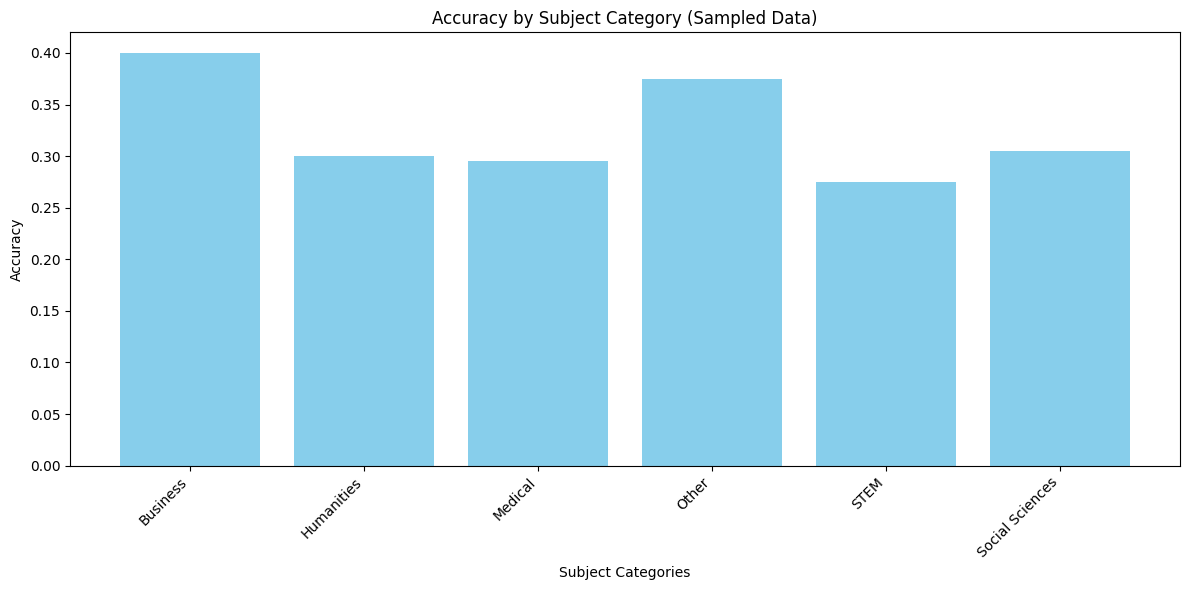

In [17]:
import matplotlib.pyplot as plt

# Prepare data for visualization
categories = list(category_accuracy.keys())
accuracies = list(category_accuracy.values())

# Plot the data
plt.figure(figsize=(12, 6))
plt.bar(categories, accuracies, color='skyblue')
plt.xlabel('Subject Categories')
plt.ylabel('Accuracy')
plt.title('Accuracy by Subject Category (Sampled Data)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [18]:
mean_accuracy = np.mean(list(category_accuracy.values()))
std_accuracy = np.std(list(category_accuracy.values()))

print(f"Mean accuracy across categories: {mean_accuracy:.3f}")
print(f"Standard deviation of accuracy across categories: {std_accuracy:.3f}")

Mean accuracy across categories: 0.325
Standard deviation of accuracy across categories: 0.046


In [2]:
# %%
from transformers import AutoModelForCausalLM, AutoTokenizer, QuantoConfig, VitsModel, TextStreamer
import time
import psutil
import torch
import whisper
import sounddevice as sd
import numpy as np
from IPython.display import Audio
from queue import Queue
import threading
import numpy as np
from openai import OpenAI
from gtts import gTTS
import os
import soundfile as sf

# %%
client = OpenAI(
    base_url="http://127.0.0.1:8080/v1",
    api_key = "sk-no-key-required"
)

# %%
# --- STT ---

whisper_model = whisper.load_model("small")

def perintah():
    duration = 5
    sample_rate = 16000  

    print("Mendengarkan......")
    audio_data = sd.rec(int(duration * sample_rate), samplerate=sample_rate, channels=1, dtype='float32')
    sd.wait()  
    print("Diterima.....")

    audio_data = np.squeeze(audio_data)  
    dengar = whisper_model.transcribe(audio_data, fp16=False, language="id")

    return dengar["text"], audio_data

# %%
# --- TTS ---

mms = VitsModel.from_pretrained("facebook/mms-tts-ind")
mms_tokenizer = AutoTokenizer.from_pretrained("facebook/mms-tts-ind")

def ngomong(text: str):
    """
    Converts text to speech using the MMS TTS model (facebook/mms-tts-ind) and plays the audio.
    Args:
        text (str): The input text to be synthesized into speech.
    """
    inputs = mms_tokenizer(text, return_tensors="pt")
    
    with torch.no_grad():
        output = mms(**inputs).waveform
    
    audio_array = output.squeeze().cpu().numpy()
    
    sample_rate = 16000  # You can adjust this based on the model's specifications if necessary
    
    sd.play(audio_array, sample_rate)
    sd.wait() 

def text_to_audio(text, output_path):
    """Converts text to audio using gTTS and saves it as an MP3 file."""
    tts = gTTS(text=text, lang="id")
    tts.save(output_path)

# %%
def get_llm_response(text: str) -> str:
     completion = client.chat.completions.create(
        model="LLaMA_CPP",
        messages=[
            {"role": "system", "content": "Tolong jawab dengan singkat kurang dari 5 kata."},
            {"role": "user", "content": text}
        ]
    )
     
     return completion.choices[0].message.content
     

# %%
def evaluate_with_audio(example):
    """
    Converts a prompt to audio, transcribes the audio, passes it to the LLM, and compares the response to the correct answer.
    Args:
        example (pd.Series): A row from the dataset containing the prompt and correct answer.
    Returns:
        bool: True if the LLM's response matches the correct answer, False otherwise.
    """
    prompt = build_prompt(example)
    audio_path = "temp_prompt.mp3"
    text_to_audio(prompt, audio_path)

    # Play the audio prompt
    data, samplerate = sf.read(audio_path)
    sd.play(data, samplerate)
    sd.wait()

    # Transcribe the audio
    transcription, _ = perintah()
    print(f"Transcription: {transcription}")

    # Generate response from LLM
    response = get_llm_response(transcription)
    print(f"LLM Response: {response}")

    # Parse the response
    parsed_response = parse_response(response)
    print(f"Parsed Response: {parsed_response}")

    return parsed_response == example.answer

# %%
def main_loop_with_global_mmlu(data):
    """
    Main loop to evaluate accuracy of global MMLU prompts using audio-based workflow.
    Args:
        data (pd.DataFrame): The sampled Global-MMLU data.
    Returns:
        dict: Accuracy per subject category.
    """
    category_accuracy = {}

    # Group data by subject_category
    for category, group in data.groupby('subject_category'):
        print(f"Evaluating category: {category}")
        result = []

        for idx, example in group.iterrows():
            is_correct = evaluate_with_audio(example)
            result.append(1 if is_correct else 0)

        category_accuracy[category] = np.mean(result)

    # Print results
    print("\nAccuracy per Subject Category:")
    for category, acc in category_accuracy.items():
        print(f"{category}: {acc:.3f}")

    return category_accuracy

# %%
from datasets import load_dataset

# Load HF dataset
language = "id"  # Choose your language here
global_mmlu = load_dataset("CohereForAI/Global-MMLU", language)
N = 100  # Limit the test dataset to the first N rows for development

# As pandas dataframe
global_mmlu.set_format("pandas")

global_mmlu_test = global_mmlu["test"][:][:N]

c:\Users\Alysha\Documents\kata-ondevice\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Alysha\Documents\kata-ondevice\myenv\lib\site-packages\whisper\__init__.py:150: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serializat

In [3]:
filtered_data = global_mmlu_test[global_mmlu_test["subject_category"] != "STEM"]

In [10]:
# %%
# Evaluate Global-MMLU dataset
if __name__ == "__main__":
    category_accuracy = main_loop_with_global_mmlu(global_mmlu_test)
    print("\nFinal Accuracy per Subject Category:")
    for category, acc in category_accuracy.items():
        print(f"{category}: {acc:.3f}")


Evaluating category: STEM
Mendengarkan......
Diterima.....
Transcription:  Terima kasih.
LLM Response: Sekali lagi.<|eot_id|>
Parsed Response: Invalid response
Mendengarkan......
Diterima.....
Transcription:  Terima kasih kerana menonton.
LLM Response: Terima kasih atas sapaan terima kasih.<|eot_id|>
Parsed Response: Invalid response
Mendengarkan......


KeyboardInterrupt: 